## Import the necessary functions 

In [1]:
# Import the necessary functions

# Personalised functions created for this NN application
from NEMO_NN_functions import *
# To convert from lat lon, to x y
from pyproj import Transformer
# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
from shapely.vectorized import contains ## Will become depreciated 
from shapely import contains_xy         ## Use this instead...
# To extract neighbouring cells
from scipy.ndimage import binary_dilation 
# To plot figures 
import matplotlib.pyplot as plt

# To create the ocean profile 
from scipy.spatial import cKDTree

# To transform coordinates from lat lon to x y 
from pyproj import Transformer

# To ensure only continuous ocean/ice shelf regions can be included
from skimage.segmentation import flood, flood_fill

## Set variables 

In [2]:
# Set the filepaths and any variables 

# NEMO simulation temperature and salinity profiles 
filepath_nemo_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc'

# Set the filepaths 
# The target grid mask 
filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_geometric_masks.nc'
# The target grid geometry
filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_geom_vars.nc'
# The eORCA1 bedmachine mask
filepath_eORCA1_bmach_masks = '/bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks.nc'

# Neural network filepaths 
path_model = '/bettik/ockendeh/NEMO_simulations/models/'
path_norm_metrics = '/bettik/ockendeh/NEMO_simulations/models/'

# And the location of the output files 
filepath_nn_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/'
simulation = 'DUM001' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 

# Any parameters which need to be set 
# Which neural network have you chosen?
this_collection = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'
exp_name = 'slope_front'
join_ice_shelves = True

### Load in the NEMO data, masks associated, and the target grid for the NN

In [3]:
# Load in the TS grid 
gridT2 = load_TSmelt_normal(filepath_nemo_output)
# Load in the mask for the ocean region 
bmach_masks = xr.open_dataset(filepath_eORCA1_bmach_masks)
mask_nocavs = bmach_masks.mask_nocavs.values
bmach_masks.close()

# Load in the mask and geometry 
masks, basins_merged, geoms = load_geom_files(filepath_geomvars, 
                                              filepath_mask, 
                                              join_ice_shelves = join_ice_shelves)
# Rename the dimensions of basins merged to be x and y 
basins_merged = basins_merged.rename({"y_grid_T": "y", "x_grid_T": "x"}).astype(int)
# Load in the coordinates for the grid 
coords = load_gridcoords(filepath_nemo_output)
# The basins mask for the NEMO 025 grid  
basins_NEMO = masks.basins_NEMO.values
if join_ice_shelves == True:
    # Dotson and Crosson?
    #basins_NEMO[basins_NEMO == 101] = 129
    # Abbot Ice Shelf
    basins_NEMO[basins_NEMO == 109] = 143
    # George VI
    basins_NEMO[basins_NEMO == 112] = 125
    # Lambert 
    basins_NEMO[basins_NEMO == 20] = 103
basin_nos = np.arange(1,156, dtype = 'float32')

You have loaded T and S: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only
You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_geom_vars.nc
You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_geometric_masks.nc
Ice shelves joined, as requested
You have loaded coordinates: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only


In [4]:
# Filepath_bedmachine 
filepath_bedmachine = '../AIAI_data/BedMachineAntarctica-v3.nc'
bmach3 = xr.open_dataset(filepath_bedmachine)
xbmach,ybmach = np.meshgrid(bmach3.x, bmach3.y)

## For the NEMO 1/4 degree grid, we want to include cells which contain ice shelf, and which are not in the NEMO 1 degree grid 

### **Calculate which points contain ice shelf**

In [6]:
# Load in the bounds of the cells
# Load in the boundaries of the cells
filepath_bounds = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/grid_eORCA025_bounds.nc'
bounds25 = xr.open_dataset(filepath_bounds)

In [7]:
# For the NEMO 1/4 degree grid, extract the bedmachine points in the cell
# calculate the fraction of each land type within the cell 

# Cell coordinates 
lat = masks.lat  # (lat)
lon = masks.lon  # (lon)
# Boundaries of the cells 
# It would be better to do this with the actual NEMO grid corners but don't have those with this mask
lon_right = lon + 0.125
lat_left = lon - 0.125
lat_top = lat + 0.025
lat_bottom = lat - 0.025
# Calculate the fraction of each land type within the cell 
do_calculation = False
if do_calculation == True:
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    fraction_OO = np.ones(masks.lat.shape) * np.nan
    fraction_IC = np.ones(masks.lat.shape) * np.nan
    fraction_GI = np.ones(masks.lat.shape) * np.nan
    fraction_IFL = np.ones(masks.lat.shape) * np.nan
    fraction_LV = np.ones(masks.lat.shape) * np.nan
    for i in range(masks.lat.shape[0]):
        for j in range(masks.lon.shape[1]):
            x_square = []
            y_square = []
            for jkl in (0,1,2,3):
                x2, y2 = transformer.transform(bounds25.lat_bnds.sel(nv4 = jkl)[i,j].values, \
                                                bounds25.lon_bnds.sel(nv4 = jkl)[i,j].values)
                x_square.append(x2)
                y_square.append(y2)
            bounds = [np.min(x_square), np.max(x_square), np.min(y_square), np.max(y_square)]
            # Extract the bedmachine mask within the boundaries of the cell 
            bmach_slice = bmach3.sel(x=slice(bounds[0], bounds[1]), y=slice(bounds[3], bounds[2]))
            if len(bmach_slice.x) == 0:
                    a = np.nan
            else:
                # List corners of rotated rectangle and create polygon
                corners = [(x_square[0], y_square[0]), (x_square[1], y_square[1]), \
                           (x_square[2], y_square[2]), (x_square[3], y_square[3])]
                poly = Polygon(corners)
                # Mask of points inside polygon
                X, Y = np.meshgrid(bmach_slice.x.values, bmach_slice.y.values)
                mask = contains_xy(poly, X, Y)
                # Extract bmach_slice inside polygon
                sub_mask = bmach_slice.mask.where(mask == True)
                # Calculate the fraction of points in the mask which are not 100% ocean/cavity
                total_points = np.sum(~np.isnan(sub_mask))
                if total_points > 0:
                    fraction_GI[i,j] = np.sum(sub_mask == 2).values/total_points
                    fraction_IFL[i,j] = np.sum(sub_mask == 1).values/total_points
                    fraction_LV[i,j] = np.sum(sub_mask == 4).values/total_points
                    fraction_OO[i,j] = np.sum(sub_mask == 0).values/total_points
                    fraction_IC[i,j] = np.sum(sub_mask == 3).values/total_points 
            print(i+1, j+1, 'out of', masks.lat.shape[0], '     ', end = '\r')
    np.savetxt('fraction_IC_025f.csv', fraction_IC)
    np.savetxt('fraction_OO_025f.csv', fraction_OO)
    np.savetxt('fraction_GI_025f.csv', fraction_GI)
    np.savetxt('fraction_IFL_025f.csv', fraction_IFL)
    np.savetxt('fraction_LV_025f.csv', fraction_LV)
else:
    # Load from file 
    print('Loading from file')
    fraction_IC  = np.loadtxt('fraction_IC_025f.csv')
    fraction_OO  = np.loadtxt('fraction_OO_025f.csv')
    fraction_GI  = np.loadtxt('fraction_GI_025f.csv')
    fraction_IFL = np.loadtxt('fraction_IFL_025f.csv')
    fraction_LV  = np.loadtxt('fraction_LV_025f.csv')



In [8]:
grounded_ice = (fraction_GI + fraction_IFL + fraction_LV)

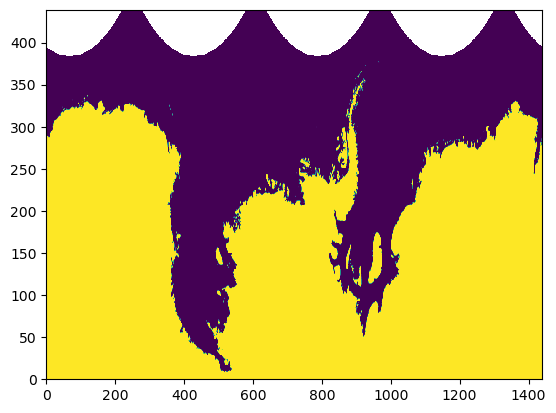

In [9]:
plt.pcolor(grounded_ice)

### **Calculate which points are included in the NEMO 1 degree grid**

In [10]:
# From the NEMO 1 degree data, we allow cells which are 
# 100% ocean
# 100% ocean+ice shelf
# 100% ice shelf 
# 100% ocean and grounded ice 

fraction_IC1  = np.loadtxt('fraction_IC.csv')
fraction_OO1  = np.loadtxt('fraction_OO.csv')
fraction_GI1  = np.loadtxt('fraction_GI.csv')
fraction_IFL1 = np.loadtxt('fraction_IFL.csv')
fraction_LV1  = np.loadtxt('fraction_LV.csv')

# Mask points which are 100% ocean and ice shelf 
mask_OOIC = fraction_IC1 + fraction_OO1
mask_OOIC[mask_OOIC < 0.9999] = 0
mask_OOIC[mask_OOIC >= 0.9999] = 1
# Mask points which are contain ocean but not ice shelf (ie 100% ocean or grounded ice) 
mask_also_allowed = (fraction_IC1 == 0) & (fraction_OO1 < 1) & (fraction_OO1 > 0)
# Sum masks 
mask_ocean = mask_OOIC + mask_also_allowed
mask_ocean[mask_ocean <1] = np.nan
mask_ocean[mask_ocean > 1] = 1

# Make sure that only cells which are continuous with the ocean get to be included
filled_ocean = flood_fill(mask_ocean, (80,150), 2, connectivity = 0)
mask_ocean[filled_ocean != 2] = np.nan

# To work out which NEMO 025 cells are in this region

from scipy.spatial import cKDTree

# Prepare NEMO 1 grid 
transformer = Transformer.from_crs("epsg:4326", "epsg:3031", always_xy=True)
x_coords, y_coords = transformer.transform(coords.nav_lon.values, coords.nav_lat.values)

# Create KDTree for NEMO 1 ocean mask
src_points = np.column_stack([x_coords.ravel(),y_coords.ravel()])
tree = cKDTree(src_points)

# Prepare NEMO 025 grid points 
x_mask, y_mask = transformer.transform(masks.lon.values, masks.lat.values)

# Create a function to make mask of nearest NEMO 1 values
def nearest(x_mask, y_mask, x_shift = 0, y_shift = 0):
    tgt_points = np.column_stack([x_mask.ravel() + x_shift,
                                  y_mask.ravel() + y_shift])
    # Query nearest neighbours
    dist, idx = tree.query(tgt_points)
    # Extract mask values at nearest neighbour locations
    nearest_values = mask_ocean.ravel()[idx]
    # Reshape back to target grid shape
    nearest_values = nearest_values.reshape(masks.lat.values.shape)
    return nearest_values

# Apply to the cell centres but with a shift each time to ensure that edges and corners are included
nv1 = nearest(x_mask, y_mask, 1000, 0)
nv2 = nearest(x_mask, y_mask, -1000, 0)
nv3 = nearest(x_mask, y_mask, 0, 1000)
nv4 = nearest(x_mask, y_mask, 0, -1000)
# Calculate a mask of the points which can be included 
nearest_total = (np.isnan(nv1)) & (np.isnan(nv2)) & (np.isnan(nv3)) & (np.isnan(nv4))
nearest_total = (nv1 != 1) | (nv2 != 1) | (nv3 != 1) | (nv4 != 1)

# Calculate a mask of the fraction of each cell to include... 
# Although might use a bedmachine mask later?
nv1[np.isnan(nv1)] = 0
nv2[np.isnan(nv2)] = 0
nv3[np.isnan(nv3)] = 0
nv4[np.isnan(nv4)] = 0
fraction_cell_include = (4 - (nv1+nv2+nv3+nv4))/4
# But then we actually only want to include regions where there is ice shelf 
fraction = fraction_cell_include*fraction_IC
fraction[fraction == 0] = np.nan

In [11]:
## We need to save the mask of the NEMO ocean cells because this is where the profiles can be extracted later 

ds = xr.Dataset(
        data_vars=dict(
            fraction_GI     = (["y", "x"], fraction_GI1.data),
            fraction_IFL    = (["y", "x"], fraction_IFL1.data),
            fraction_LV     = (["y", "x"], fraction_LV1.data),
            fraction_OO     = (["y", "x"], fraction_OO1.data),
            fraction_IC     = (["y", "x"], fraction_IC1.data),
            mask_nocavs     = (["y", "x"], mask_ocean.data),
            ),
        coords=dict(
            lon=(("y", "x"), coords.nav_lon.values),
            lat=(("y", "x"), coords.nav_lat.values),    ),
        attrs=dict(description = "Masks of eORCA1 derived from Bedmachine v3", 
                  ),
    )
filepath_eORCA1 = '/bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks.nc'
ds.to_netcdf(filepath_eORCA1)
print('You have saved the following file')
print(filepath_eORCA1)
ds.close()

You have saved the following file
/bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks.nc


## Create the mask needed to apply the neural network over this area 

In [12]:
## For the mask we need
# Ocean only, All cavities, Closed cavities, Open cavities, Grounded Ice, Basins_NEMO

In [13]:
closed_cavities = (fraction_IC > 0) & (nearest_total == 1)
closed_cavities_nan = np.where(closed_cavities, 1, np.nan)
open_cavities = (fraction_IC > 0) & (nearest_total == 0)
open_cavities_nan = np.where(open_cavities, 1, np.nan)
ocean_only = fraction_OO > 0
ocean_only_nan = np.where(ocean_only, 1, np.nan)
grounded_ice = (grounded_ice)  == 1
grounded_ice_nan = np.where(grounded_ice, 1, np.nan)
all_cavities = open_cavities + closed_cavities
all_cavities_nan = np.where(all_cavities, 1, np.nan)
open_cav_ocean = open_cavities + ocean_only
open_cav_ocean_nan = np.where(open_cav_ocean, 1, np.nan)

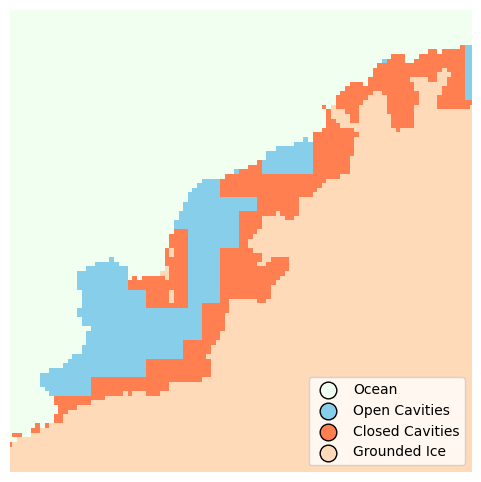

In [14]:
fig, ax = plt.subplots(1,1, figsize = (6,6))
from matplotlib.colors import ListedColormap
im = plt.imshow(ocean_only_nan, cmap = ListedColormap(["honeydew"]), origin = 'lower')
plt.scatter(-0,-0, color = 'honeydew', label = 'Ocean')
im = plt.imshow(open_cavities_nan, cmap = ListedColormap(["skyblue"]), origin = 'lower')
plt.scatter(-0,-0, color = 'skyblue', label = 'Open Cavities')
im = plt.imshow(closed_cavities_nan, cmap = ListedColormap(["coral"]), origin = 'lower')
plt.scatter(-0,-0, color = 'coral', label = 'Closed Cavities')
im = plt.imshow(grounded_ice_nan, cmap = ListedColormap(["peachpuff"]), origin = 'lower')
plt.scatter(-0,-0, color = 'peachpuff', label = 'Grounded Ice')
im.set_clim(0.8,2)
leg = ax.legend(loc = 4, markerscale = 2, fontsize = 10)
for h in leg.legend_handles:
    h.set_edgecolor("black")
    h.set_linewidth(1.0)
    
ax.axis('off')
ax.set_xlim(1030,1130);
ax.set_ylim(190,290);

In [15]:
# Save one file for the 
ds = xr.Dataset(
        data_vars=dict(
            ocean_only              = (["y", "x"], ocean_only.data),
            ocean_only_nan          = (["y", "x"], ocean_only_nan.data),
            all_cavities            = (["y", "x"], all_cavities.data),
            all_cavities_nan        = (["y", "x"], all_cavities_nan.data),
            closed_cavities         = (["y", "x"], closed_cavities.data),
            closed_cavities_nan     = (["y", "x"], closed_cavities_nan.data),
            open_cavities           = (["y", "x"], open_cavities.data),
            open_cavities_nan       = (["y", "x"], open_cavities_nan.data),
            ocean_open_cavities     = (["y", "x"], open_cav_ocean.data),
            ocean_open_cavities_nan = (["y", "x"], open_cav_ocean.data),
            grounded_ice            = (["y", "x"], grounded_ice.data),
            grounded_ice_nan        = (["y", "x"], grounded_ice_nan.data),    
            basins_NEMO             = (["y", "x"], basins_NEMO.data),
            ),
        coords=dict(
            lon=(("y", "x"), masks.lon.values),
            lat=(("y", "x"), masks.lat.values),    ),
        attrs=dict(description="Masks for grounded ice, floating ice and open ocean from Bedmachine Antarctica v3", 
                  ),
    )
filepath_new_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc'
ds.to_netcdf(filepath_new_mask)
print('You have saved the following file')
print(filepath_new_mask)

You have saved the following file
/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc


## To accompany this mask we also need:
**Bathymetry, ice shelf draft (and slopes), distance to GL, distance to OO, distance to OC, fraction of melt to keep**

In [17]:
# Cell coordinates 
lat = masks.lat.values  # (lat)
lon = masks.lon.values  # (lon)
# Boundaries of the cells 
# It would be better to do this with the actual NEMO grid corners but don't have those with this mask
#lon_right = lon + 0.125
#lon_left = lon - 0.125
#lat_top = lat + 0.025
#lat_bottom = lat - 0.025

In [20]:
from tqdm import tqdm

In [40]:
do_calculation = True
if do_calculation == True:
    # Calculate the bathymetry and ice shelf draft within each cell 
    transformer = Transformer.from_crs("epsg:4326","epsg:3031",always_xy=True)
    # Create empty arrays 
    mean_bedelev = np.ones(masks.lat.shape) * np.nan
    mean_draft = np.ones(masks.lat.shape) * np.nan
    #for i in tqdm(range(200,210)):
    #    for j in range(200,210):
    for i in tqdm(range(masks.lat.shape[0])):
        for j in range(masks.lon.shape[1]):
            pass 
            # Only calculate masks for region we actually need it 
            if closed_cavities_nan[i,j] == 1:
                x_square = []
                y_square = []
                for jkl in (0,1,2,3):
                    lat_jkl = bounds25.lat_bnds.sel(nv4 = jkl)[i,j].values
                    lon_jkl = bounds25.lon_bnds.sel(nv4 = jkl)[i,j].values
                    x2, y2 = transformer.transform(lon_jkl, lat_jkl)
                    x_square.append(x2)
                    y_square.append(y2)
                bounds = [np.nanmin(x_square), np.nanmax(x_square), np.nanmin(y_square), np.nanmax(y_square)]
                # Extract the bedmachine mask within the boundaries of the cell 
                bmach_slice = bmach3.sel(x=slice(bounds[0], bounds[1]), y=slice(bounds[3], bounds[2]))
                if len(bmach_slice.x) == 0:
                    a = np.nan
                else:
                    X, Y = np.meshgrid(bmach_slice.x.values, bmach_slice.y.values)
                    # List corners of rotated rectangle and create polygon
                    corners = [(x_square[0], y_square[0]), (x_square[1], y_square[1]), \
                           (x_square[2], y_square[2]), (x_square[3], y_square[3])]
                    poly = Polygon(corners)# Mask of points inside polygon
                    mask = contains_xy(poly, X, Y)
                    # Extract bmach_slice inside polygon
                    sub_mask = bmach_slice.mask.where(mask == True)
                    # IF WE ARE IN THE ICE SHELF REGION
                    # Extract only values in ice shelf region
                    sub_mask1 = xr.where(sub_mask == 3, True, False)
                    sub_mask2 = xr.where(sub_mask > -1, True, False)
                    if np.sum(sub_mask1) > 0:
                        mask_bmach = bmach_slice.where(sub_mask1 == True)
                        mean_bedelev[i,j] = mask_bmach.bed.mean()
                        mean_draft[i,j] = (mask_bmach.surface - mask_bmach.thickness).mean()
                    else:
                        mask_bmach = bmach_slice.where(sub_mask2 == True)
                        mean_bedelev[i,j] = mask_bmach.bed.mean()
                        mean_draft[i,j] = (mask_bmach.surface - mask_bmach.thickness).mean()     
    np.savetxt('bathy_BM3.csv', mean_bedelev)
    np.savetxt('draft_BM3.csv', mean_draft)
else:
    # Load from file 
    mean_bedelev  = np.loadtxt('bathy_BM3.csv')
    mean_draft  = np.loadtxt('draft_BM3.csv')
    print('Bathymetry and Ice Shelf draft loaded from file')

100%|█████████████████████████████████████████| 439/439 [07:09<00:00,  1.02it/s]


/tmp/ipykernel_2228036/3542204668.py:3: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(orientation = 'horizontal', shrink = 0.2, pad = -0.2)


(np.float64(0.0), np.float64(1440.0), np.float64(0.0), np.float64(439.0))

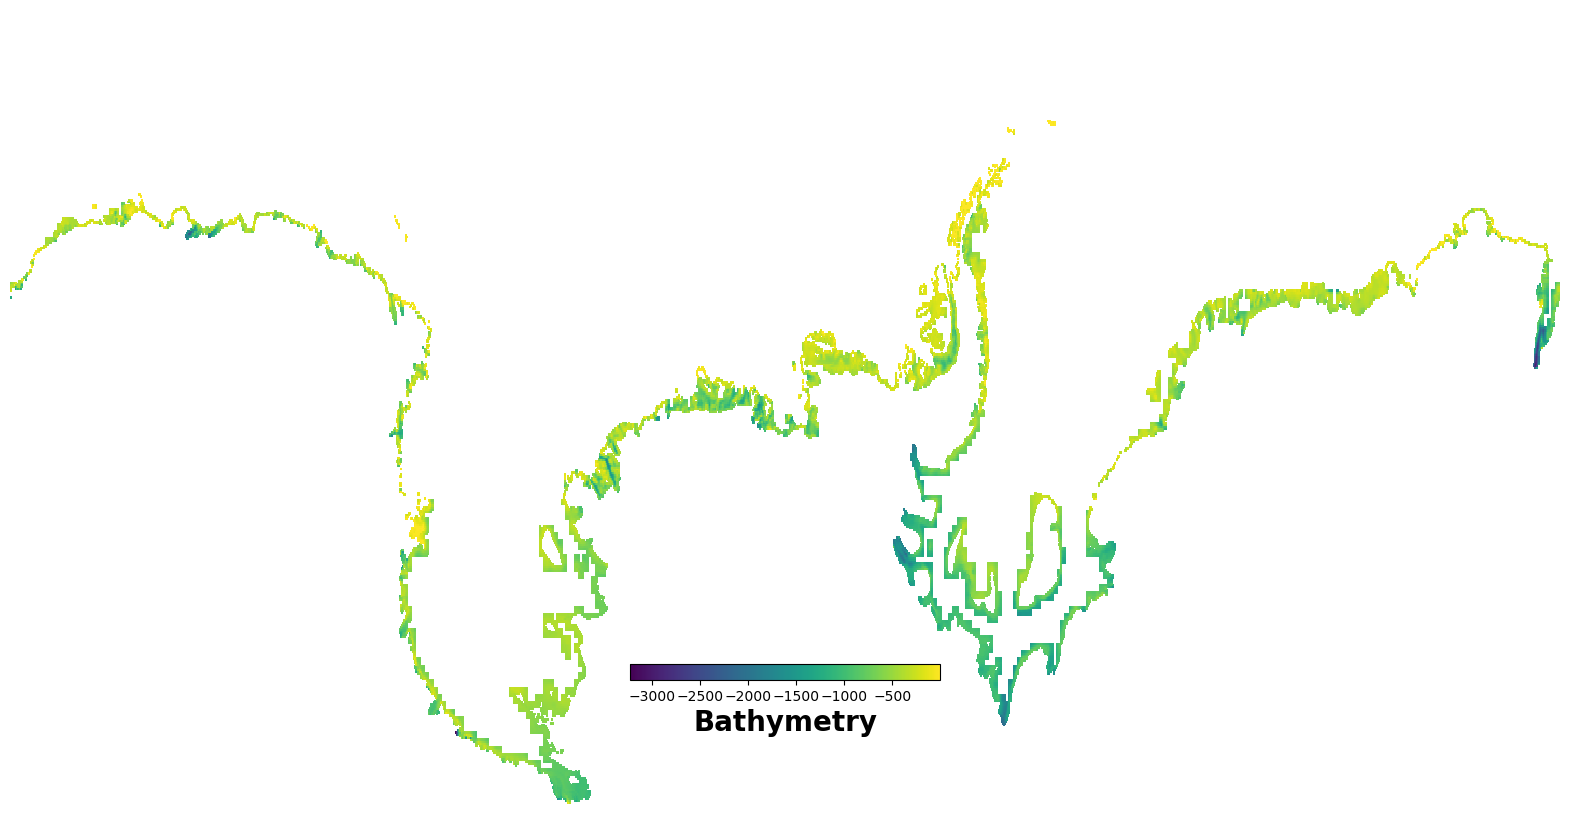

In [41]:
fig, ax = plt.subplots(1,1, figsize = (20,10))
plt.pcolor(mean_bedelev)
cbar = plt.colorbar(orientation = 'horizontal', shrink = 0.2, pad = -0.2)
cbar.set_label('Bathymetry', fontweight = 'bold', fontsize = 20)
ax.axis('off')
#plt.clim(10,0)

In [42]:
# And for each point in the mask, the distance to the nearest grounded cell, nearest open ocean cell and nearest open cavity/ocean

In [43]:
# Create files of distances and slopes
# Create a pyproj transform to go from lat lon to polar stereo
transformer = Transformer.from_crs("epsg:4326","epsg:3031")

# Create a list of all the points in closed ice shelves 
CC_lat, CC_lon = masks.lat.data[closed_cavities == 1], masks.lon.data[closed_cavities == 1]
CC_x, CC_y = transformer.transform(CC_lat, CC_lon)
points_CC = np.array(list(zip(CC_x, CC_y)))
# Create a list of all the grounded ice points
GL_lat, GL_lon = masks.lat.data[grounded_ice == 1], masks.lon.data[grounded_ice == 1]
GL_x, GL_y = transformer.transform(GL_lat, GL_lon)
points_GL = np.array(list(zip(GL_x, GL_y)))
# Create a list of all the open ocean points 
OO_lat, OO_lon = masks.lat.data[ocean_only == 1], masks.lon.data[ocean_only == 1]
OO_x, OO_y = transformer.transform(OO_lat, OO_lon)
points_OO = np.array(list(zip(OO_x, OO_y)))
# Create a list of all the open ocean cavity points
OC_lat, OC_lon = masks.lat.data[open_cav_ocean == 1], masks.lon.data[open_cav_ocean == 1]
OC_x, OC_y = transformer.transform(OC_lat, OC_lon)
points_OC = np.array(list(zip(OC_x, OC_y)))

# Create the cKD Tree for the grounding line 
tree = cKDTree(points_GL)
# Query the cKD Tree for the closed cavity points 
dist, index = tree.query(points_CC, k = 1)
distances_GL = np.ones(masks.lat.data.shape)*np.nan
distances_GL[closed_cavities == 1] = dist

# Create the cKD Tree for the open ocean
tree = cKDTree(points_OO)
# Query the cKD Tree for the closed cavity points 
dist, index = tree.query(points_CC, k = 1)
distances_OO = np.ones(masks.lat.data.shape)*np.nan
distances_OO[closed_cavities == 1] = dist

# Create the cKD Tree for the open ocean and cavities
tree = cKDTree(points_OC)
# Query the cKD Tree for the closed cavity points 
dist, index = tree.query(points_CC, k = 1)
distances_OC = np.ones(masks.lat.data.shape)*np.nan
distances_OC[closed_cavities == 1] = dist

/tmp/ipykernel_2228036/3999763855.py:4: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(orientation = 'horizontal', shrink = 0.2, pad = -0.2)


(np.float64(0.0), np.float64(1440.0), np.float64(0.0), np.float64(439.0))

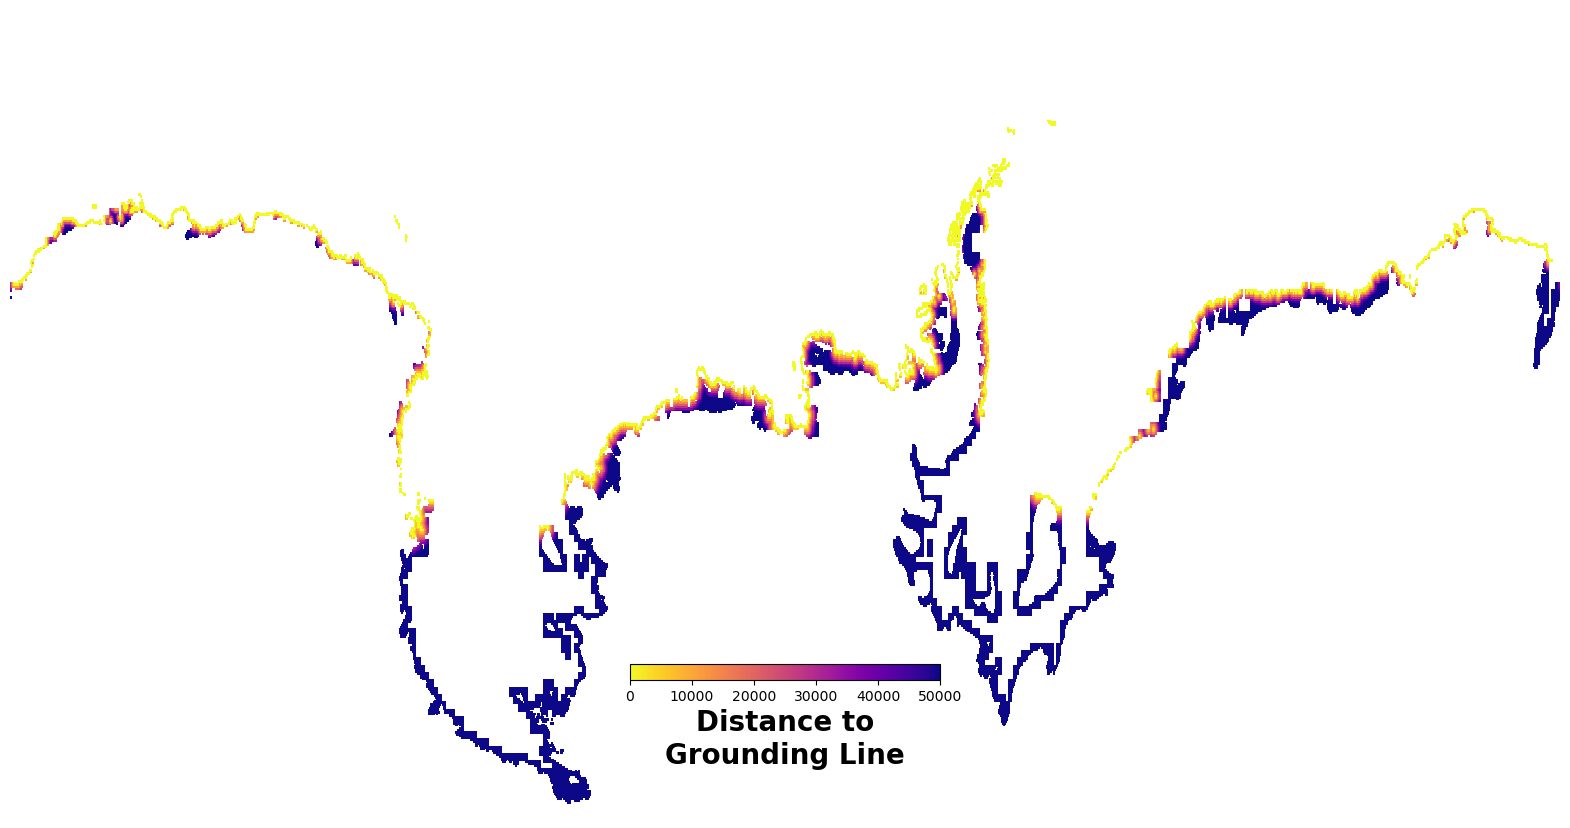

In [45]:
fig, ax = plt.subplots(1,1, figsize = (20,10))
im = plt.pcolor(distances_OO, cmap = 'plasma_r')
im.set_clim(0,50000)
cbar = plt.colorbar(orientation = 'horizontal', shrink = 0.2, pad = -0.2)
cbar.set_label('Distance to\nGrounding Line', fontweight = 'bold', fontsize = 20)
ax.axis('off')
#plt.clim(10,0)

In [23]:
# In order to calculate the slopes we need the distance between points, 
# and because the points are on the NEMO lat-lon grid we need to convert them to polar stereo the calculate the distances 
# Create a pyproj transformer to transform onto polar stereo
lat, lon = masks.lat.data, masks.lon.data
grid_x, grid_y = transformer.transform(lat, lon)
# Use the np.roll function to move the data slightly 
shifted_x_p0 = (grid_x - np.roll(grid_x, shift = 1, axis = 0))
shifted_x_m0 = (grid_x - np.roll(grid_x, shift = -1, axis = 0))
shifted_x_p1 = (grid_x - np.roll(grid_x, shift = 1, axis = 1))
shifted_x_m1 = (grid_x - np.roll(grid_x, shift = -1, axis = 1))
shifted_y_p0 = (grid_y - np.roll(grid_y, shift = 1, axis = 0))
shifted_y_m0 = (grid_y - np.roll(grid_y, shift = -1, axis = 0))
shifted_y_p1 = (grid_y - np.roll(grid_y, shift = 1, axis = 1))
shifted_y_m1 = (grid_y - np.roll(grid_y, shift = -1, axis = 1))
# Because you need to calculate the hypotenuse distance you need x and y for both directions of shift 
shifted_p_lon = np.sqrt(shifted_x_p0**2 + shifted_y_p0**2) # lon
shifted_m_lon = np.sqrt(shifted_x_m0**2 + shifted_y_m0**2) # lon 
shifted_p_lat = np.sqrt(shifted_x_p1**2 + shifted_y_p1**2) # lat
shifted_m_lat = np.sqrt(shifted_x_m1**2 + shifted_y_m1**2) # lat

In [24]:
bathymetry = mean_bedelev
isf_draft = mean_draft
interface = isf_draft*all_cavities_nan
interface_p_lon = ( + interface - np.roll(interface, shift = 1, axis = 0))/shifted_p_lon
interface_m_lon = (- interface + np.roll(interface, shift = -1, axis = 0))/shifted_m_lon
interface_p_lat = (+ interface - np.roll(interface, shift = 1, axis = 1))/shifted_p_lat
interface_m_lat = (- interface + np.roll(interface, shift = -1, axis = 1))/shifted_m_lat
bathymetry = bathymetry*all_cavities_nan
bathymetry_p_lon = ( + bathymetry - np.roll(bathymetry, shift = 1, axis = 0))/shifted_p_lon
bathymetry_m_lon = (- bathymetry + np.roll(bathymetry, shift = -1, axis = 0))/shifted_m_lon
bathymetry_p_lat = (+ bathymetry - np.roll(bathymetry, shift = 1, axis = 1))/shifted_p_lat
bathymetry_m_lat = (- bathymetry + np.roll(bathymetry, shift = -1, axis = 1))/shifted_m_lat
# Take the mean to get the actual local slope (and account for bendy points)
slope_isdraft_lon = np.nansum((interface_p_lon,interface_m_lon), axis = 0)/2
slope_isdraft_lat = np.nansum((interface_p_lat,interface_m_lat), axis = 0)/2
slope_bathy_lon = np.nansum((bathymetry_p_lon,bathymetry_m_lon), axis = 0)/2
slope_bathy_lat = np.nansum((bathymetry_p_lat,bathymetry_m_lat), axis = 0)/2
print('Local meridional and zonal slopes')

Local meridional and zonal slopes


In [25]:
print('If you have calculated the slopes properly, then there shouldn\'t be any nan values')
print('The following numbers should all be 0')
print(np.sum(np.isnan(slope_isdraft_lon)), np.sum(np.isnan(slope_isdraft_lat)), np.sum(np.isnan(slope_bathy_lon)), \
      np.sum(np.isnan(slope_bathy_lat)))

If you have calculated the slopes properly, then there shouldn't be any nan values
The following numbers should all be 0
0 0 0 0


In [26]:
basin_nos = np.unique(basins_NEMO)

In [27]:
# To calculate the rotated slopes then we need to look at things on a basin by basin basisd
direction_to_front = np.ones(masks.lat.data.shape) * np.nan
no_cav_basins = []
#basin_no = 1
for jj in range(len(basin_nos)):
    basin_no = int(basin_nos[jj])
    mask_basin = xr.where((basins_NEMO == basin_no), 1, np.nan)
    x_basin = CC_x[basins_NEMO[closed_cavities_nan == 1] == basin_no]
    y_basin = CC_y[basins_NEMO[closed_cavities_nan == 1] == basin_no]
    if len(x_basin) > 0:
        mean_x_basin = np.mean(x_basin)
        mean_y_basin = np.mean(y_basin)
        nearest_points_i = index[basins_NEMO[closed_cavities_nan == 1] == basin_no]
        nearest_x_i = np.ones(len(np.unique(nearest_points_i)))
        nearest_y_i = np.ones(len(np.unique(nearest_points_i)))
        for i in range(len(np.unique(nearest_points_i))):
            nearest_x_i[i], nearest_y_i[i] = OC_x[np.unique(nearest_points_i)[i]], \
                                                   OC_y[np.unique(nearest_points_i)[i]]
        mean_x_i = np.mean(nearest_x_i)
        mean_y_i = np.mean(nearest_y_i)
        direction = np.arctan2(mean_x_basin - mean_x_i, mean_y_basin - mean_y_i)
    else:
        direction = np.nan
        no_cav_basins.append(basin_no)
    #print(jj,len(x_basin), len(nearest_points_i),direction)
    direction_to_front[mask_basin == 1] = np.ones(int(np.nansum(mask_basin))) * direction
print('No closed cavities in the following basins:')
print(no_cav_basins)

No closed cavities in the following basins:
[96, 154]


In [28]:
# Then rotate the calculated slopes to have the slope towards the ice front and the slope across the ice front 
slope_isdraft_hypot = np.sqrt(slope_isdraft_lon **2 + slope_isdraft_lat **2)
angle_isdraft = np.arctan2(slope_isdraft_lon,slope_isdraft_lat)- direction_to_front
slope_is_across_front = slope_isdraft_hypot * np.sin(angle_isdraft)
slope_is_towards_front = slope_isdraft_hypot * np.cos(angle_isdraft)
slope_bathy_hypot = np.sqrt(slope_bathy_lon **2 + slope_bathy_lat **2)
angle_bathy = np.arctan2(slope_bathy_lon,slope_bathy_lat)- direction_to_front
slope_ba_across_front = slope_bathy_hypot * np.sin(angle_bathy)
slope_ba_towards_front = slope_bathy_hypot * np.cos(angle_bathy)
print('Rotated slopes')

Rotated slopes


In [29]:
print('If you have calculated the slopes properly, then there shouldn\'t be any nan values')
print('The following numbers should all be 0')
print(np.sum(np.isnan(slope_is_across_front[closed_cavities == 1])), np.sum(np.isnan(slope_is_towards_front[closed_cavities == 1])), 
      np.sum(np.isnan(slope_ba_across_front[closed_cavities == 1])), np.sum(np.isnan(slope_ba_towards_front[closed_cavities == 1])))

If you have calculated the slopes properly, then there shouldn't be any nan values
The following numbers should all be 0
0 0 0 0


In [30]:
bathymetry

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [31]:
# And then save these to file 
# Note that bathymetry and isf_draft need to be positive (hopefully this doesn't cause confusion later) 
ds = xr.Dataset(
            data_vars=dict(
                areas                  = (["y", "x"], geoms.areas.data),
                fraction               = (["y", "x"], fraction.data),
                bathymetry             = (["y", "x"], -bathymetry),
                isf_draft              = (["y", "x"], -isf_draft),
                distances_GL           = (["y", "x"], distances_GL.data),
                distances_OO           = (["y", "x"], distances_OO.data),
                distances_OC           = (["y", "x"], distances_OC.data),
                slope_isdraft_lon      = (["y", "x"], slope_isdraft_lon.data),
                slope_isdraft_lat      = (["y", "x"], slope_isdraft_lat.data),
                slope_bathy_lon        = (["y", "x"], slope_bathy_lon.data),
                slope_bathy_lat        = (["y", "x"], slope_bathy_lat.data),
                slope_is_across_front  = (["y", "x"], slope_is_across_front.data),
                slope_is_towards_front = (["y", "x"], slope_is_towards_front.data),
                slope_ba_across_front  = (["y", "x"], slope_ba_across_front.data),
                slope_ba_towards_front = (["y", "x"], slope_ba_towards_front.data),
                ),
            coords=dict(
                lon=(("y", "x"), masks.lon.data),
                lat=(("y", "x"), masks.lat.data),    ),
            attrs=dict(description = "Required geometry variables for the BMv3 geometry", 
                       ),
                )
filepath_geomvars_new = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc'
ds.to_netcdf(filepath_geomvars_new)
print('You have saved the following file')
print(filepath_geomvars_new)


You have saved the following file
/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc


In [32]:
from pyproj import Transformer
import numpy as np

transformer = Transformer.from_crs("epsg:4326", "epsg:3031", always_xy=True)

lon = coords.bounds_nav_lon.values  # shape (y, x, 4)
lat = coords.bounds_nav_lat.values  # shape (y, x, 4)

# Flatten for vectorized transform
lon_flat = lon.reshape(-1)
lat_flat = lat.reshape(-1)

x_proj, y_proj = transformer.transform(lon_flat, lat_flat)

# Reshape back to (y, x, 4)
x_proj = x_proj.reshape(lon.shape)
y_proj = y_proj.reshape(lat.shape)

from matplotlib.collections import PolyCollection
ny, nx, nv = lon.shape

# Build polygons in projected space
polys = np.stack([x_proj, y_proj], axis=-1).reshape(ny * nx, nv, 2)
mask = mask_ocean.reshape(ny * nx)

# Create RGBA colors: default transparent
colors = np.zeros((ny * nx, 4))
colors[:, 3] = 0.0   # alpha = 0 (fully transparent)

# Set polygons with value == 1 to skyblue
#skyblue = np.array([135/255, 206/255, 235/255, 1.0])  # RGBA
#colors[mask == 1] = skyblue

N = ny * nx
# Default: fully transparent edges
edge = np.zeros((N, 4))
edge[:, 3] = 0.0   # alpha = 0
# Set edges for mask==1 polygons
import matplotlib.colors as mcolors
rgba = mcolors.to_rgba("grey") 
edge[mask.reshape(-1) == 1] = rgba


In [33]:
values = bmach3.mask.values
values = values.astype('float32')
values[values == 0] = np.nan
values[values == 4] = 2
values[values == 1] = 2
values[values == 3] = 1

In [34]:
bounds = np.min(bmach3.x.values), np.max(bmach3.x.values), np.min(bmach3.y.values), np.max(bmach3.y.values)

In [35]:
masks.lon.values[masks.closed_cavities_nan == 1] 

array([-152.77846, -154.12903, -153.69621, ...,  -60.5    ,  -60.75   ,
        -60.5    ], dtype=float32)

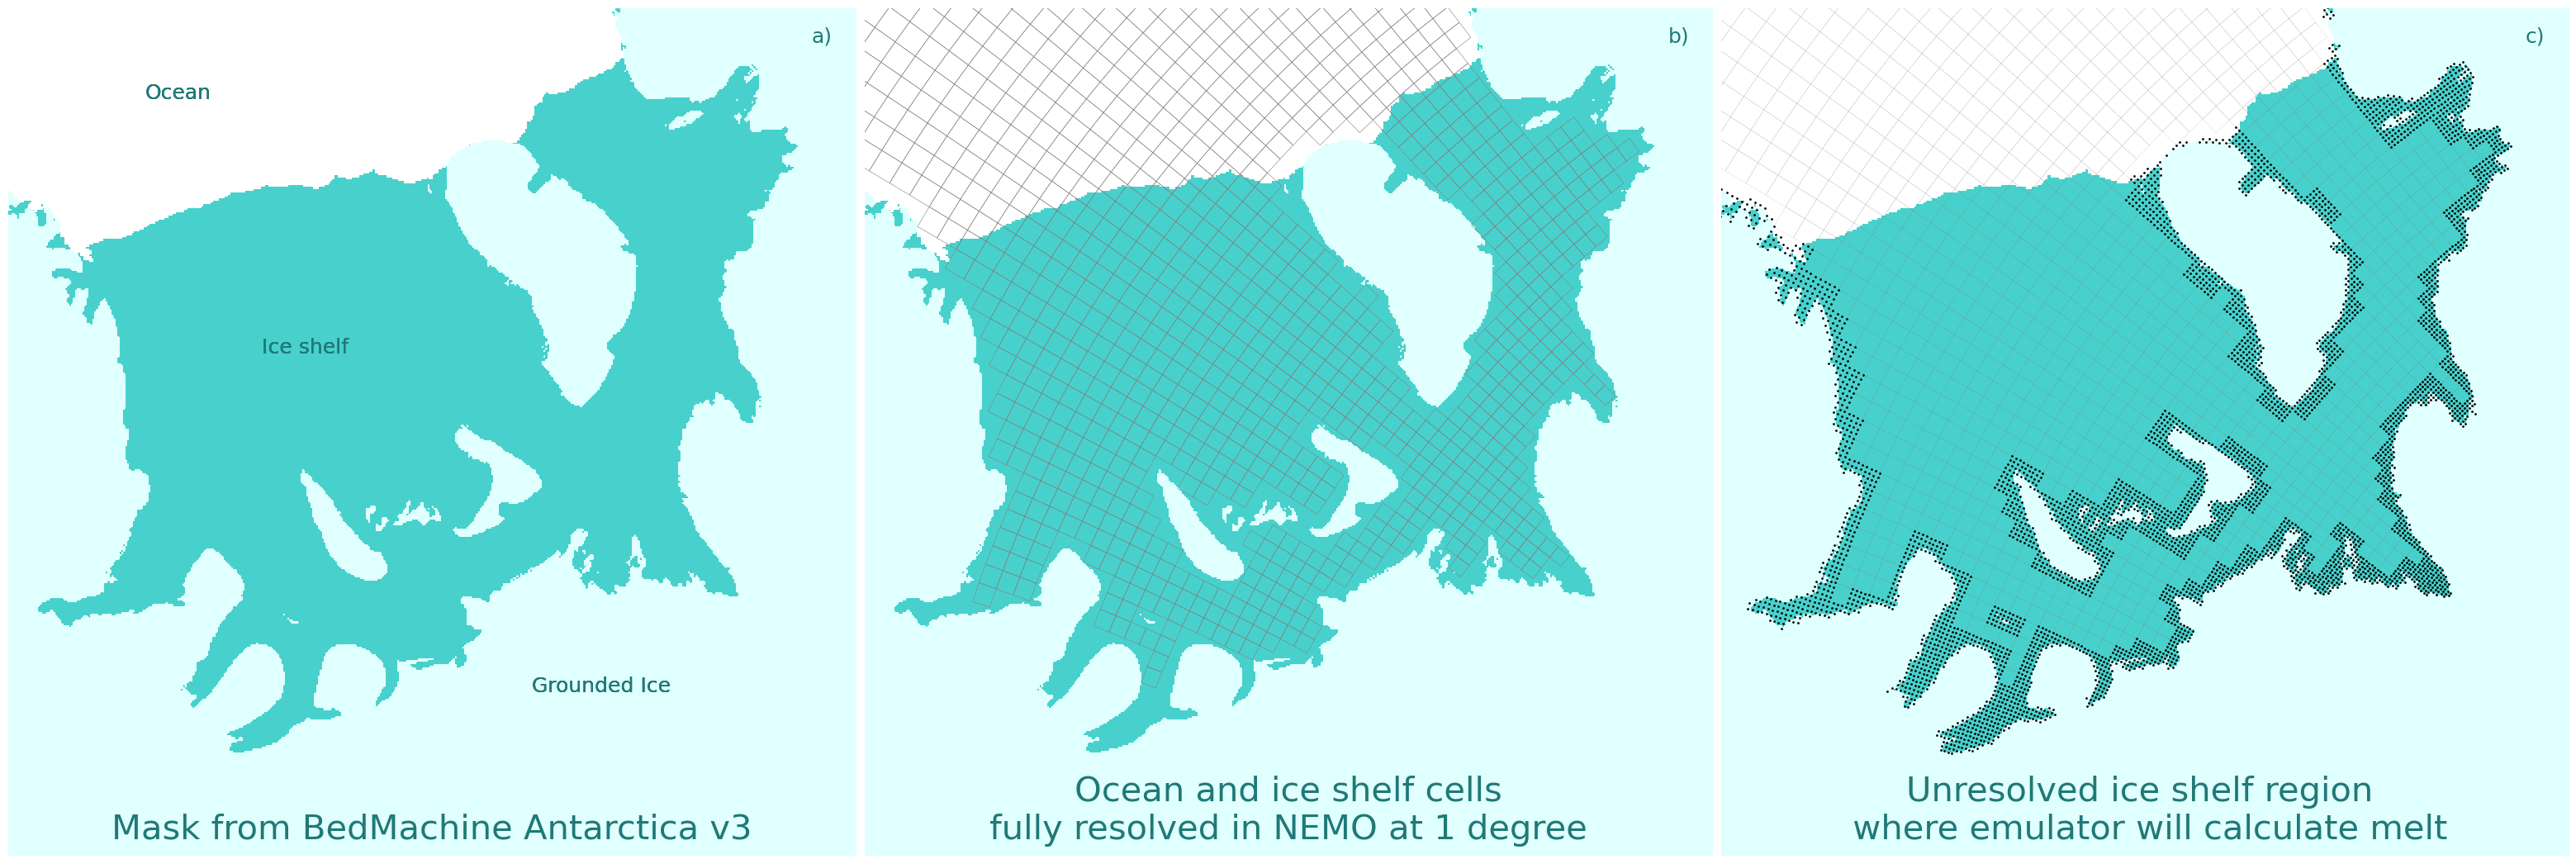

In [36]:
fig, axs = plt.subplots(1,3, figsize = (40,40))
cmap = mcolors.ListedColormap(['mediumturquoise', 'lightcyan'])
plt.subplots_adjust(wspace = 0.01)

pc = PolyCollection( polys, facecolors=colors, edgecolors=edge, linewidth = 0.4) 
axs[1].add_collection(pc)
pc = PolyCollection( polys, facecolors=colors, edgecolors=edge, linewidth = 0.1) 
axs[2].add_collection(pc)

axs[1].plot((0,1),(0,1), color = 'grey', label = 'Ice shelf resolved in NEMO 1 degree')

xIC, yIC = transformer.transform(masks.lon.values[(fraction_IC > 0) & (nearest_total == 1)], \
                                 masks.lat.values[(fraction_IC > 0) & (nearest_total == 1)])
axs[2].scatter(xIC, yIC, s = 1, c = 'k', marker = 'o', label = 'Ice shelf resolved by neural network')

#plt.scatter(0,0, color = 'mediumturquoise', label = 'Ice shelf (Bedmachine v3)', s = 20)
#plt.scatter(0,0, color = 'lightcyan',       label = 'Land and grounded ice (Bedmachine v3)', s = 20)


#plt.legend(loc = (0,1.01), fontsize = 40, markerscale = 10)
#xIC2, yIC2 = transformer.transform(masks.lon.values[masks.closed_cavities_nan == 1] , \
#                                 masks.lat.values[masks.closed_cavities_nan == 1])
#plt.scatter(xIC2, yIC2, s = 60, c = 'red', marker = 'o', zorder = 0)

ann_kw = dict(
    xy=(0, 0),
    xycoords='axes fraction',
    fontsize=18,
    color = '#1f7977ff',
    ha='center',
    va='center'
)

titles = ('Mask from BedMachine Antarctica v3', 'Ocean and ice shelf cells\nfully resolved in NEMO at 1 degree', \
          'Unresolved ice shelf region \n where emulator will calculate melt')
labels = ('a)', 'b)', 'c)')
for i in range(3):
    im = axs[i].imshow(values[::5,::5], cmap = cmap, extent = bounds)
    im.set_clim(0.5,2.5)
    axs[i].set_xlim(-1.55e6, -0.45e6);
    axs[i].set_ylim(0e6, 1.1e6);
    axs[i].axis('off');
    axs[0].annotate('Ocean', xytext = (0.2,0.9), **ann_kw)
    axs[0].annotate('Grounded Ice', xytext = (0.7,0.2), **ann_kw)
    axs[0].annotate('Ice shelf', xytext = (0.35,0.6), **ann_kw)
    axs[i].annotate(titles[i], xy = (0,0), xytext = (0.5,0.02), ha = 'center', xycoords = 'axes fraction', fontsize = 30, color = '#1f7977ff')
    axs[i].annotate(labels[i], xy = (0,0), xytext = (0.96,0.96), ha = 'center', xycoords = 'axes fraction', fontsize = 18, color = '#1f7977ff')
    
fig.savefig('FIGURES/Mask_apply_NN.png', dpi = 200, bbox_inches = 'tight')

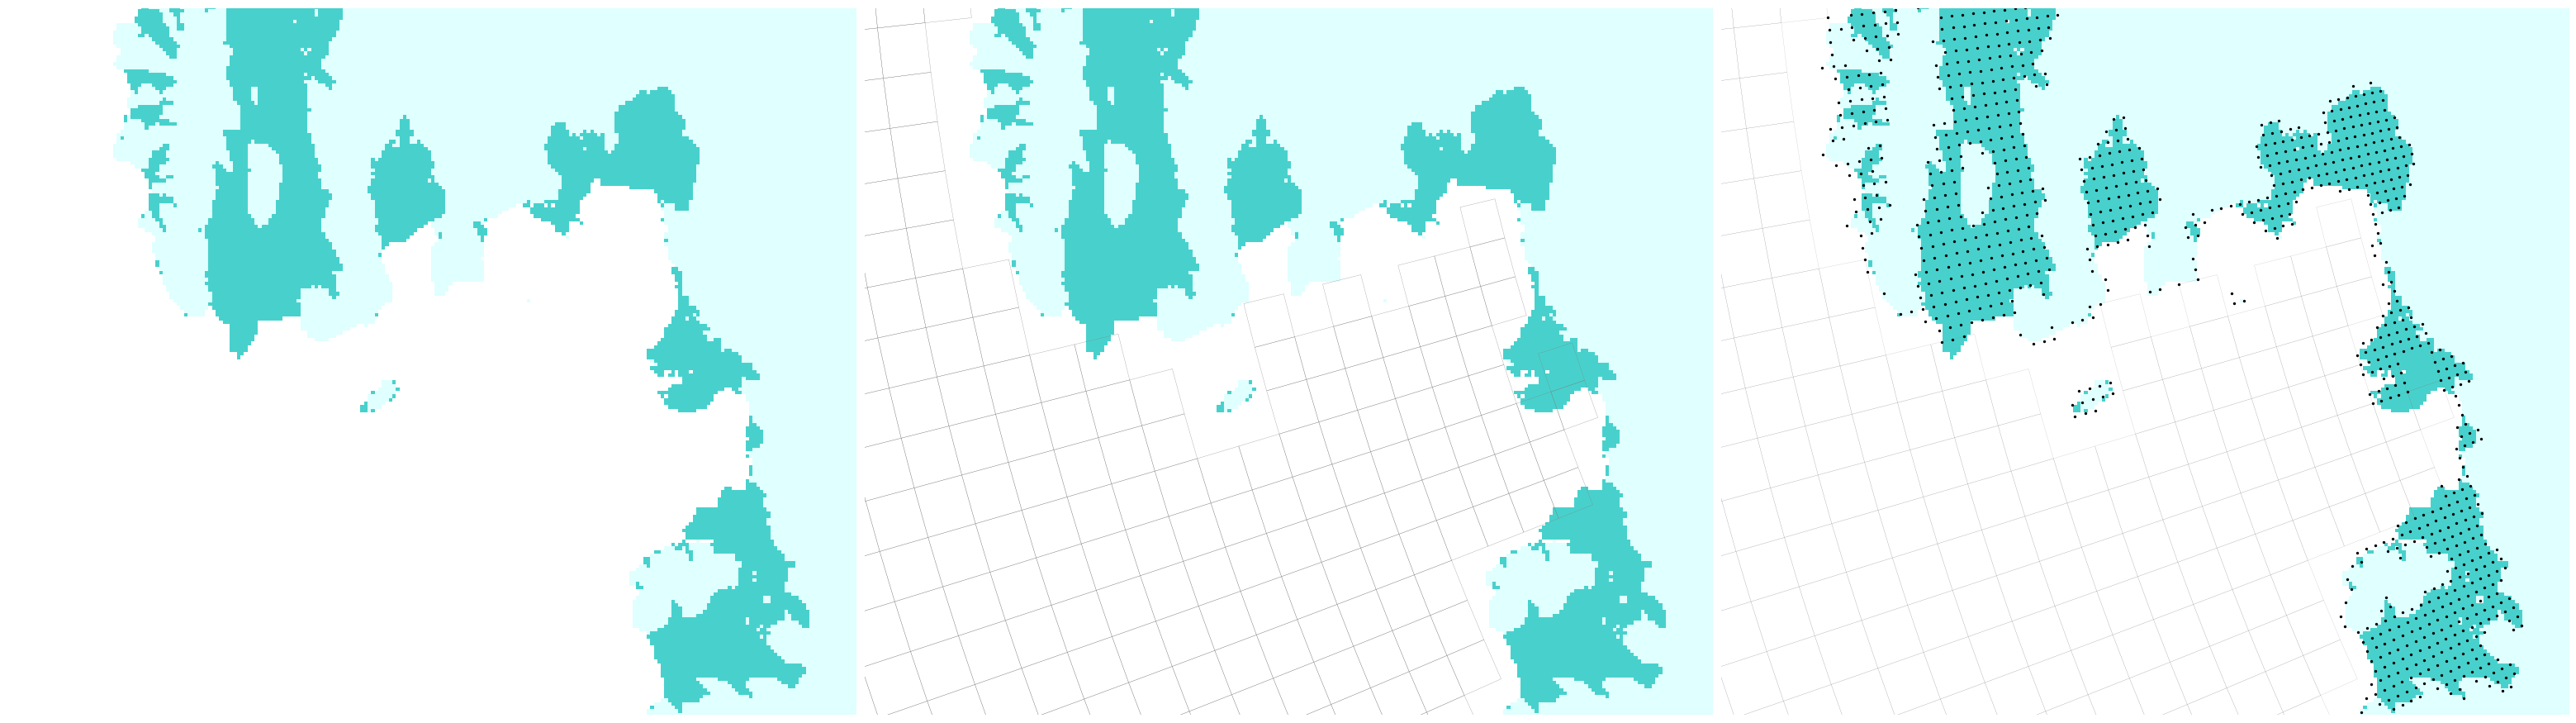

In [37]:
fig, axs = plt.subplots(1,3, figsize = (40,40))
cmap = mcolors.ListedColormap(['mediumturquoise', 'lightcyan'])
plt.subplots_adjust(wspace = 0.01)

pc = PolyCollection( polys, facecolors=colors, edgecolors=edge, linewidth = 0.2) 
axs[1].add_collection(pc)
pc = PolyCollection( polys, facecolors=colors, edgecolors=edge, linewidth = 0.1) 
axs[2].add_collection(pc)

#plt.plot((0,1),(0,1), color = 'grey', label = 'Ice shelf resolved in NEMO 1 degree')

xIC, yIC = transformer.transform(masks.lon.values[(fraction_IC > 0) & (nearest_total == 1)], \
                                 masks.lat.values[(fraction_IC > 0) & (nearest_total == 1)])
axs[2].scatter(xIC, yIC, s = 2, c = 'k', marker = 'o', label = 'Ice shelf resolved by neural network')

#plt.scatter(0,0, color = 'mediumturquoise', label = 'Ice shelf (Bedmachine v3)', s = 20)
#plt.scatter(0,0, color = 'lightcyan',       label = 'Land and grounded ice (Bedmachine v3)', s = 20)


#plt.legend(loc = (0,1.01), fontsize = 40, markerscale = 10)
#xIC2, yIC2 = transformer.transform(masks.lon.values[masks.closed_cavities_nan == 1] , \
#                                 masks.lat.values[masks.closed_cavities_nan == 1])
#plt.scatter(xIC2, yIC2, s = 60, c = 'red', marker = 'o', zorder = 0)

for i in range(3):
    im = axs[i].imshow(values[::5,::5], cmap = cmap, extent = bounds)
    im.set_clim(0.5,2.5)
    axs[i].set_xlim(-2.05e6, -1.45e6);
    axs[i].set_ylim(-0.7e6, -0.2e6);
    axs[i].axis('off');

#fig.savefig('FIGURES/legend.png', dpi = 200, bbox_inches = 'tight')

## Compare my NEMO mask to Clara's mask 

In [38]:
# Load in Clara's mask 
mask_clara = xr.open_dataset('/bettik/burgardc/DATA/FOR_HELEN/mask_unresolved_points_eORCA1_BedMachine2km.nc')
quad_melt = xr.open_dataset('/bettik/burgardc/DATA/FOR_HELEN/info_quad_meltparam_isf_129basins.nc')
xclara, yclara = np.meshgrid(mask_clara.x, mask_clara.y)

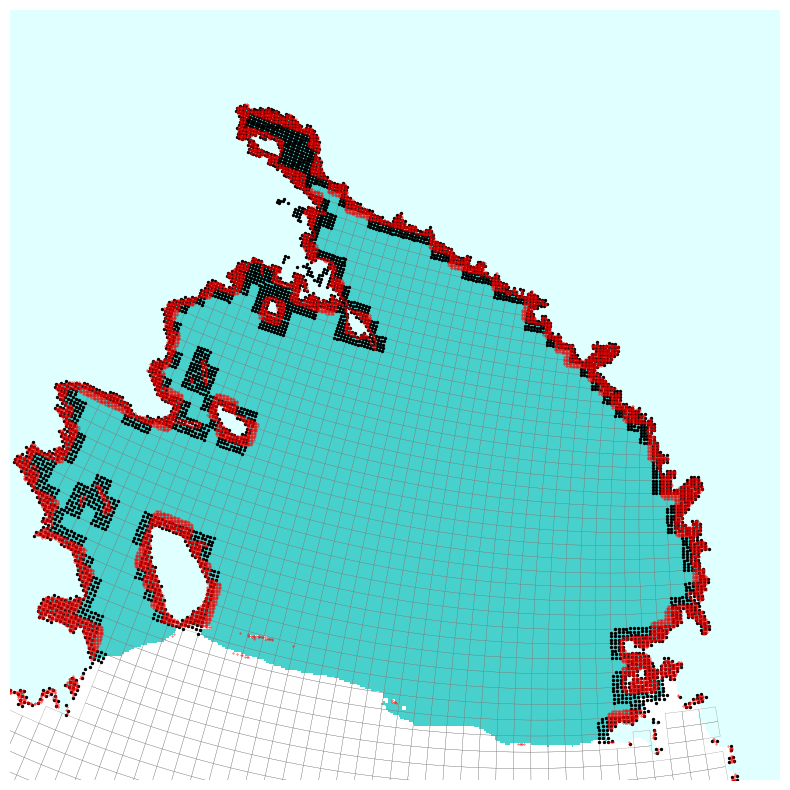

In [39]:
fig, axs = plt.subplots(1,1, figsize = (10,10))
plt.subplots_adjust(wspace = 0.01)

# Plot the NEMO grid cell outlines 
pc = PolyCollection( polys, facecolors=colors, edgecolors=edge, linewidth = 0.2) 
axs.add_collection(pc)

# Plot the NEMO 1/4 degree cells resolved by the neural network 
xIC, yIC = transformer.transform(masks.lon.values[(fraction_IC > 0) & (nearest_total == 1)], \
                                 masks.lat.values[(fraction_IC > 0) & (nearest_total == 1)])
axs.scatter(xIC, yIC, s = 2, c = 'k', marker = 'o', label = 'Ice shelf resolved by neural network')

# Plot the BedMachine Antarctica v3 mask 
cmap = mcolors.ListedColormap(['mediumturquoise', 'lightcyan'])
im = axs.imshow(values[::5,::5], cmap = cmap, extent = bounds)
im.set_clim(0.5,2.5)

# Plot the points where clara will apply her parameterisation 
axs.scatter(xclara[mask_clara.unresolved_isf_points.values == True], \
            yclara[mask_clara.unresolved_isf_points == True], s = 0.1, marker = 'o', c = 'red')

which_region = 'Ross'

regions = {
    "PineIsland":     (-2.05e6, -1.45e6, -0.7e6, -0.2e6),
    "FilchnerRonne":  (-1.55e6, -0.45e6, 0e6, 1.1e6),
    "Brunt":          (-0.75e6, 0e6, 1.1e6, 2.3e6),
    "Amery":          (1.6e6, 2.3e6, 0.5e6, 1.0e6),
    "Ross":           (-0.6e6, 0.5e6, -1.4e6, -0.3e6),
}

bounds_h = regions[which_region]
axs.set_xlim(bounds_h[0],bounds_h[1])
axs.set_ylim(bounds_h[2],bounds_h[3])

axs.axis('off');

fig.savefig('FIGURES/' + which_region + '.jpg', dpi = 200, bbox_inches = 'tight')

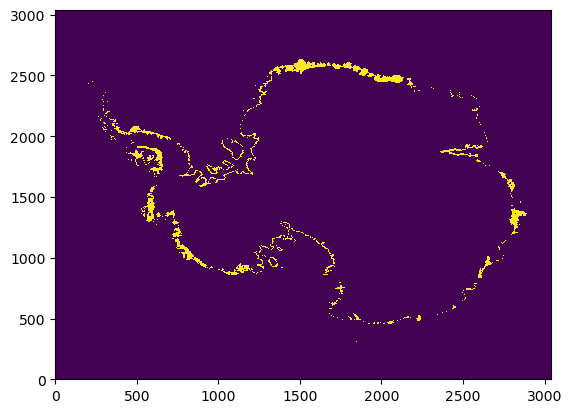

In [40]:
plt.pcolor(mask_clara.unresolved_isf_points)

(np.float64(-1500000.0),
 np.float64(-500000.0),
 np.float64(0.0),
 np.float64(1000000.0))

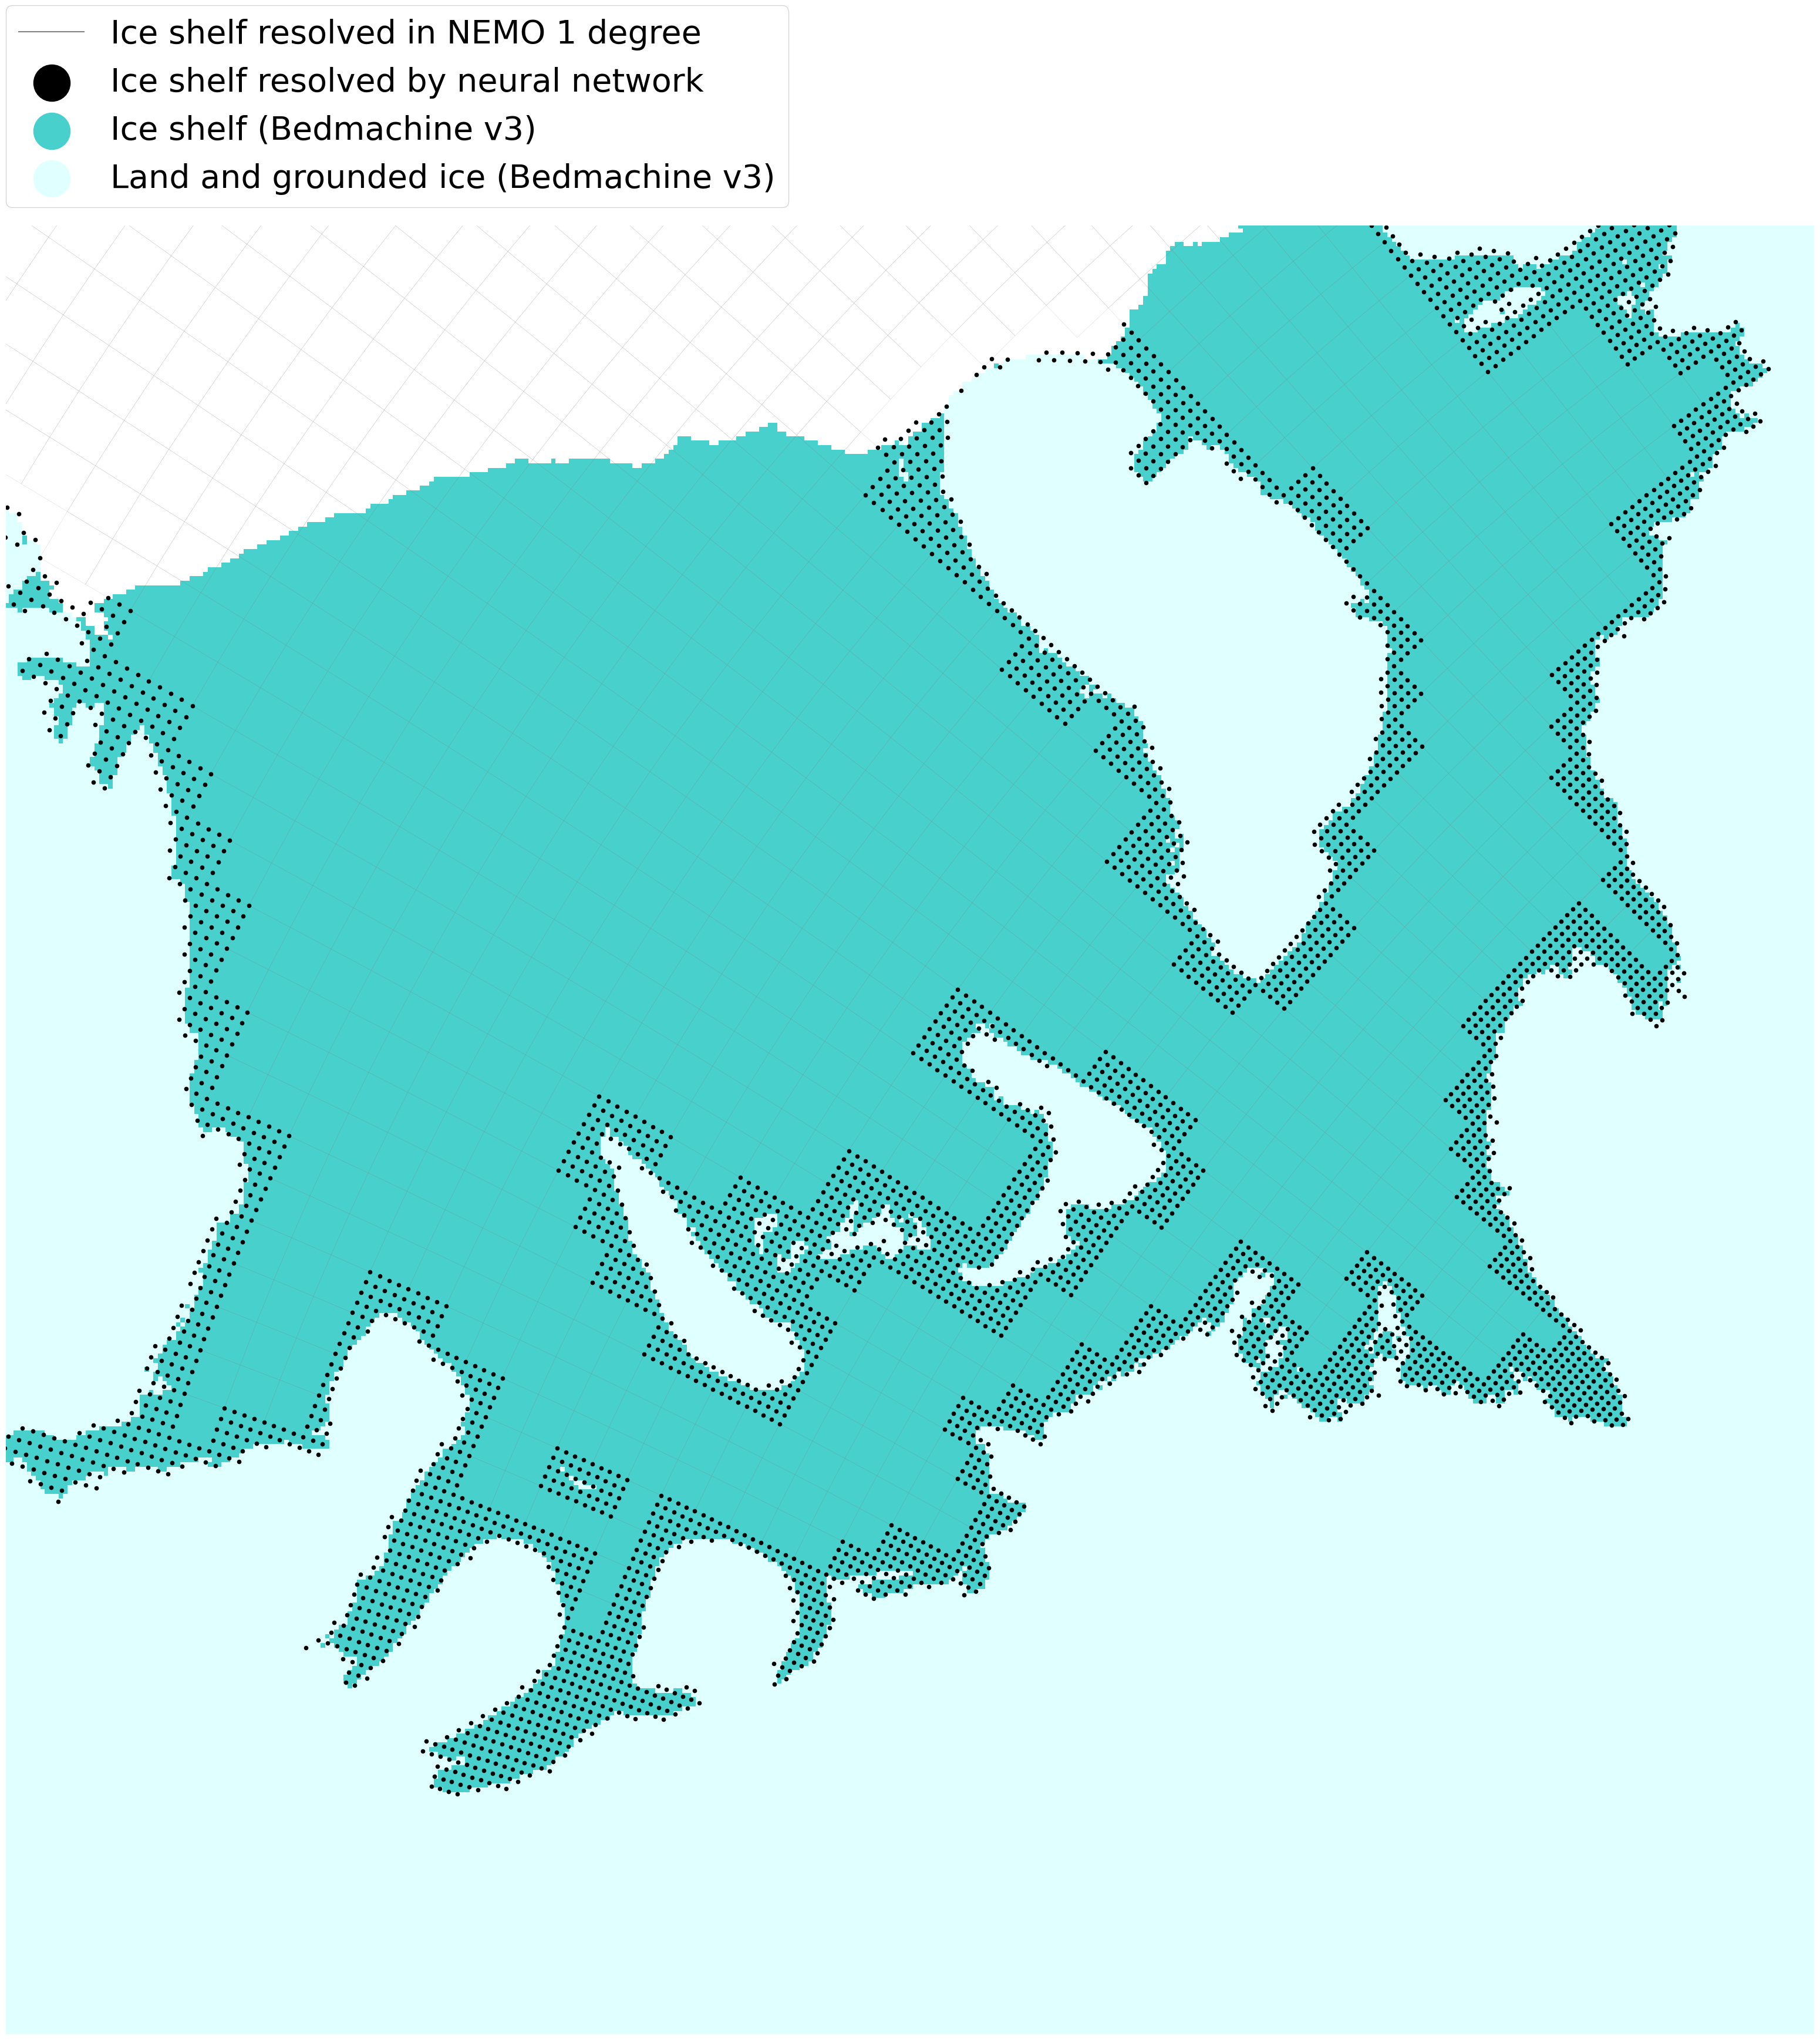

In [41]:
fig, ax = plt.subplots(1,1, figsize = (40,40))
cmap = mcolors.ListedColormap(['mediumturquoise', 'lightcyan'])
im = plt.imshow(values[::5,::5], cmap = cmap, extent = bounds)

pc = PolyCollection( polys, facecolors=colors, edgecolors=edge, linewidth = 0.1) 
ax.add_collection(pc)

plt.plot((0,1),(0,1), color = 'grey', label = 'Ice shelf resolved in NEMO 1 degree')

xIC, yIC = transformer.transform(masks.lon.values[(fraction_IC > 0) & (nearest_total == 1)], \
                                 masks.lat.values[(fraction_IC > 0) & (nearest_total == 1)])
plt.scatter(xIC, yIC, s = 20, c = 'k', marker = 'o', label = 'Ice shelf resolved by neural network')

plt.scatter(0,0, color = 'mediumturquoise', label = 'Ice shelf (Bedmachine v3)', s = 20)
plt.scatter(0,0, color = 'lightcyan',       label = 'Land and grounded ice (Bedmachine v3)', s = 20)


plt.legend(loc = (0,1.01), fontsize = 40, markerscale = 10)
#xIC2, yIC2 = transformer.transform(masks.lon.values[masks.closed_cavities_nan == 1] , \
#                                 masks.lat.values[masks.closed_cavities_nan == 1])
#plt.scatter(xIC2, yIC2, s = 60, c = 'red', marker = 'o', zorder = 0)

im.set_clim(0.5,2.5)
ax.set_xlim(-1.5e6, -0.5e6)
ax.set_ylim(0e6, 1.0e6)
ax.axis('off')

#fig.savefig('FIGURES/legend.png', dpi = 200, bbox_inches = 'tight')

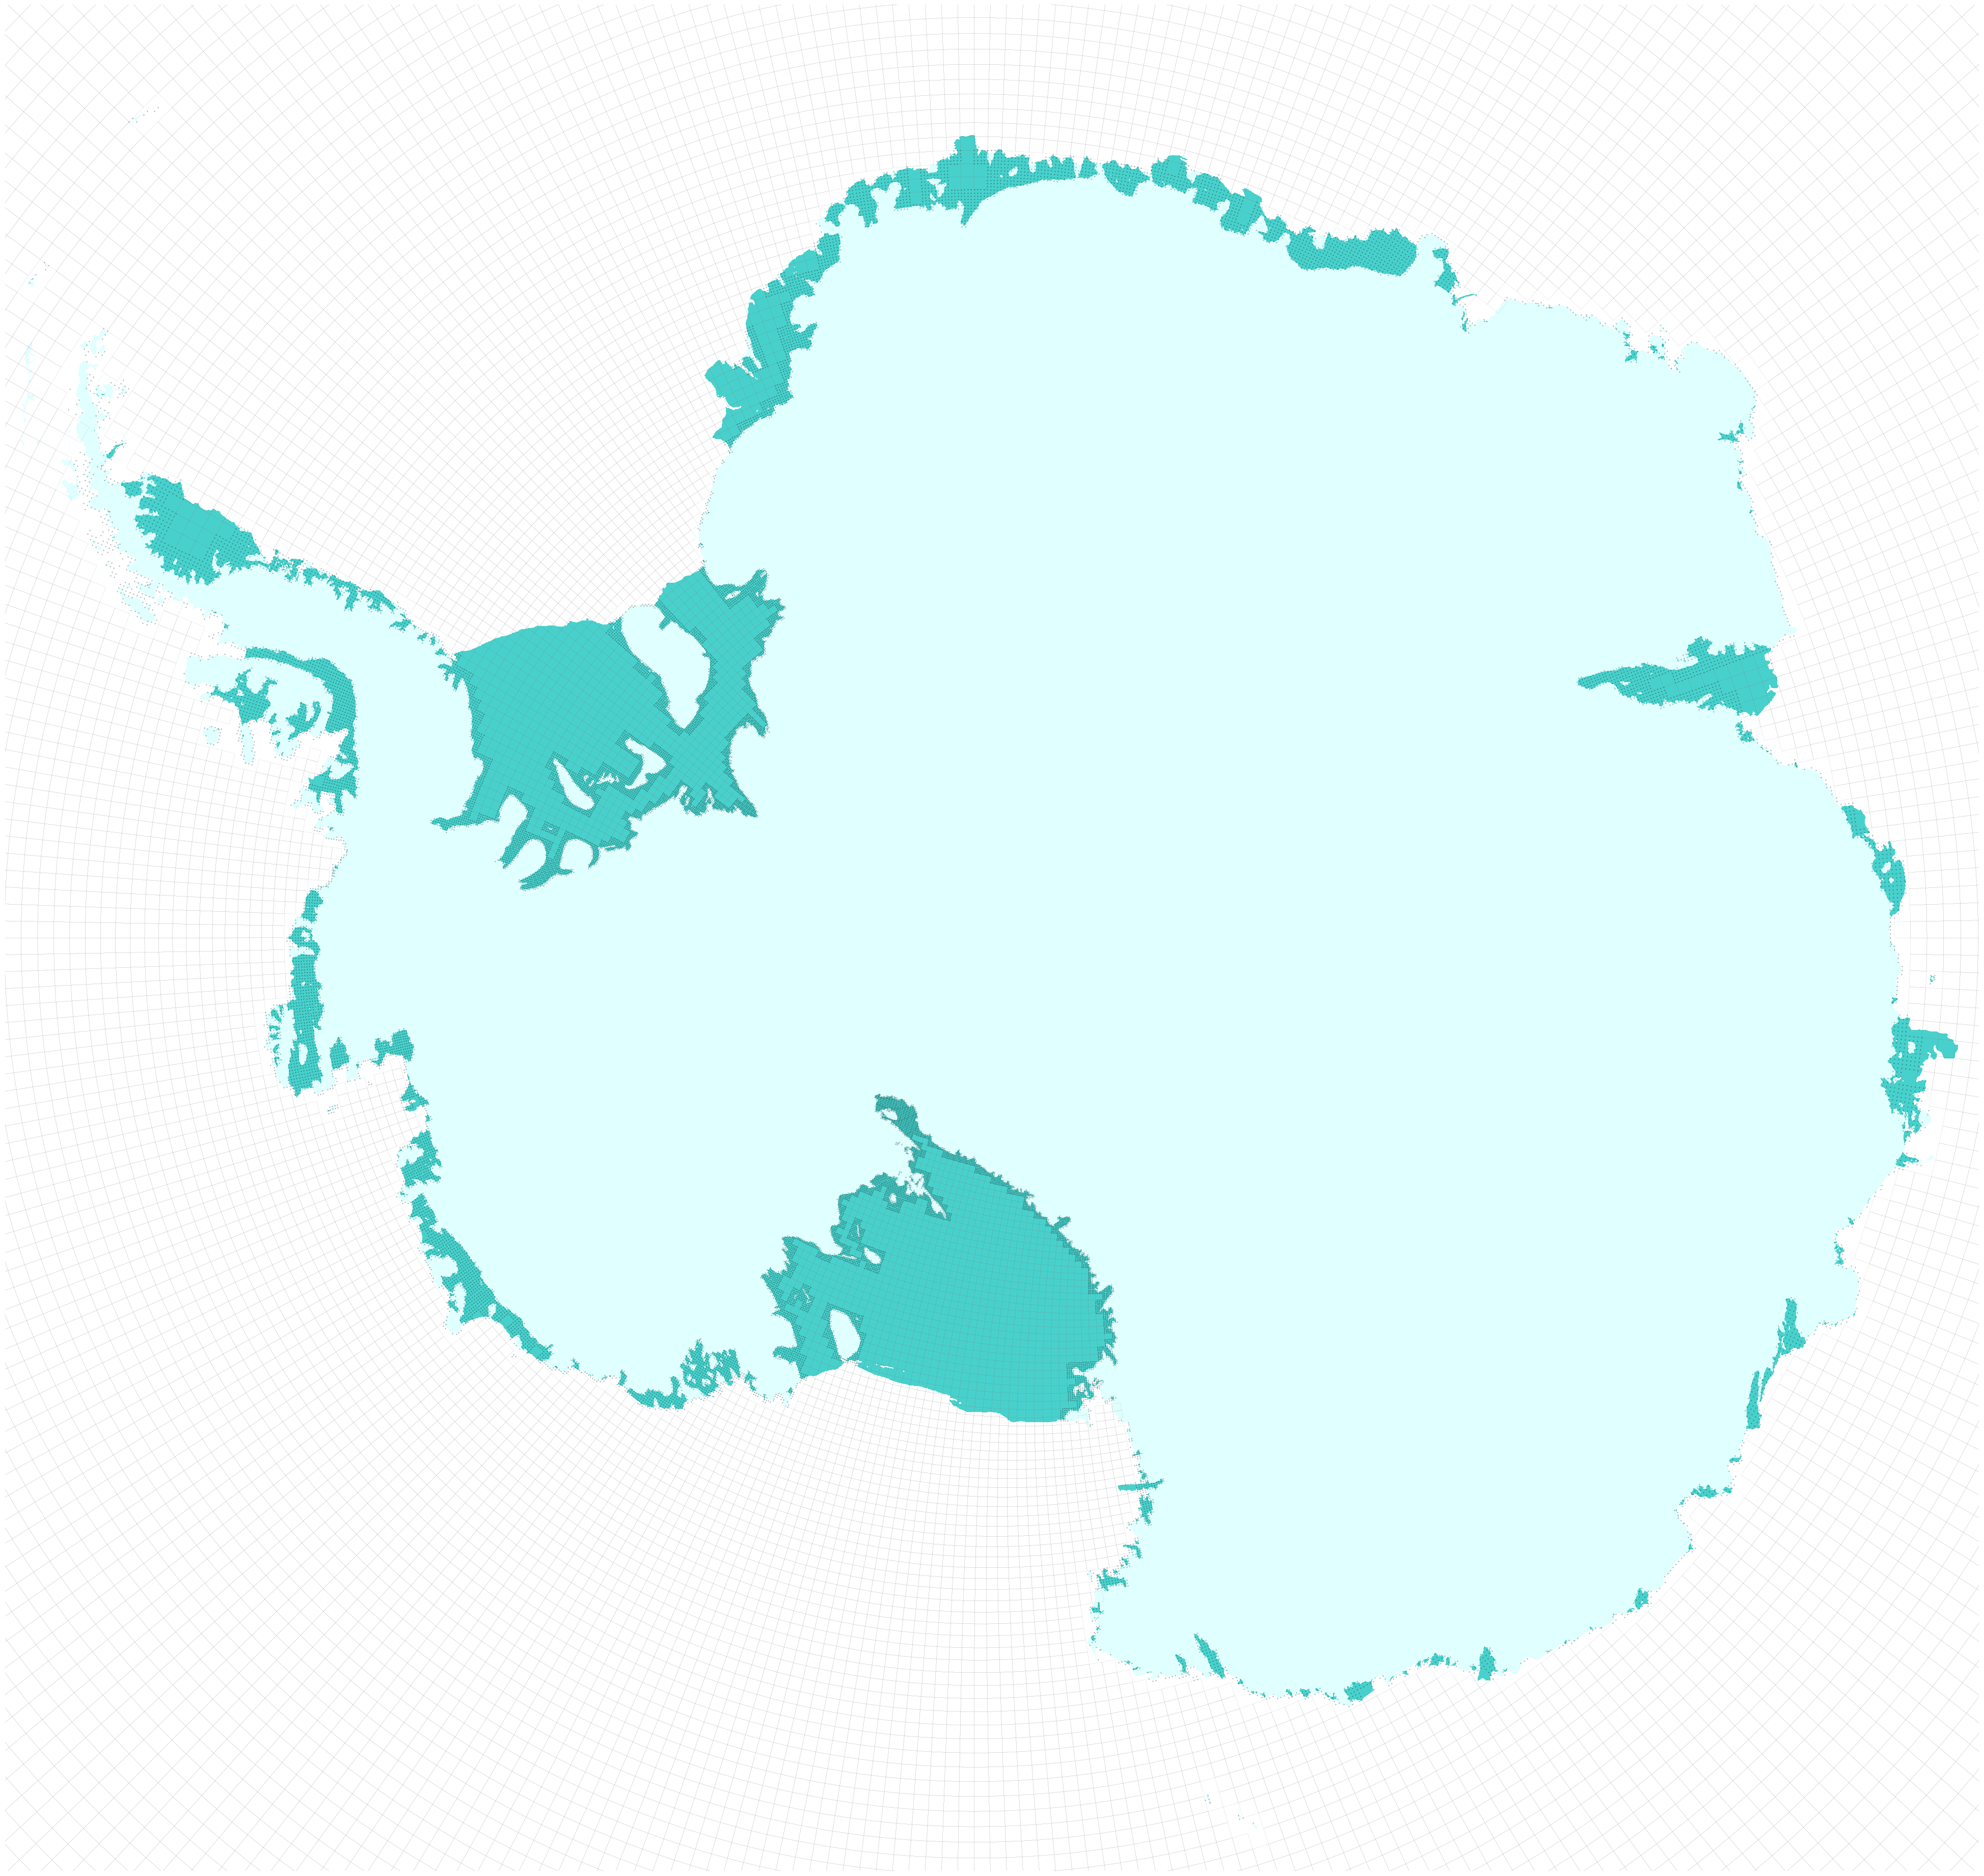

In [42]:
fig, ax = plt.subplots(1,1, figsize = (50,50))
cmap = mcolors.ListedColormap(['mediumturquoise', 'lightcyan'])
im = plt.imshow(values[::1,::1], cmap = cmap, extent = bounds)

pc = PolyCollection( polys, facecolors=colors, edgecolors=edge, linewidth = 0.1) 
ax.add_collection(pc)

#xIC, yIC = transformer.transform(masks.lon.values[fraction_IC > 0], masks.lat.values[fraction_IC > 0])
xIC, yIC = transformer.transform(masks.lon.values[(fraction_IC > 0) & (nearest_total == 1)], \
                                 masks.lat.values[(fraction_IC > 0) & (nearest_total == 1)])
plt.scatter(xIC, yIC, s = 0.05, c = 'k', marker = 'o')

im.set_clim(0.5,2.5)
ax.set_xlim(-2.7e6,2.8e6)
ax.set_ylim(-2.6e6, 2.6e6)
ax.axis('off')

plt.savefig('FIGURES/map.png', dpi = 500, bbox_inches = 'tight')

In [ ]:
# A very tedious map correction
fraction_IC[166, 433] = 1
fraction_IC[171, 432] = 0
fraction_IC[170, 432] = 0.2
fraction_IC[169, 432] = 0.4
fraction_IC[168, 433] = 0.6
fraction_IC[167, 433] = 0.8
fraction_IC[160:166, 433] = 1
fraction_IC[150:159, 434] = 1
fraction_IC[142:150, 435] = 1
fraction_IC[135:143, 436] = 1
fraction_IC[128:135, 437] = 1
fraction_IC[121:128, 438] = 1
fraction_IC[115:121, 439] = 1
fraction_IC[110:115, 440] = 1
fraction_IC[104:110, 441] = 1
fraction_IC[99:104, 442] = 1
fraction_IC[94:99, 443] = 1
fraction_IC[89:94, 444] = 1
fraction_IC[84:89, 445] = 1
fraction_IC[80:84, 446] = 1
fraction_IC[75:80, 447] = 1
fraction_IC[71:75, 448] = 1
fraction_IC[67:71, 449] = 1
fraction_IC[63:67, 450] = 1
fraction_IC[59:63, 451] = 1
fraction_IC[55:59, 452] = 1
fraction_IC[51:55, 453] = 1
fraction_IC[47:51, 454] = 1
fraction_IC[43:47, 455] = 1
fraction_IC[40:43, 456] = 1
fraction_IC[36:40, 457] = 1
fraction_IC[33:36, 458] = 1
fraction_IC[32, 458] = 0.8
fraction_IC[31, 459] = 0.6
fraction_IC[30, 459] = 0.5
fraction_IC[29, 459] = 0.4
fraction_IC[172:181, 432] = 0
fraction_IC[182:196, 431] = 0
fraction_IC[196:218, 430] = 0
fraction_IC[219:384, 429] = 0
fraction_IC[384:440, 429] = np.nan

In [ ]:

groundedice[33:36, 458] = 0
groundedice[36:40, 457] = 0
groundedice[40:43, 456] = 0
groundedice[43:47, 455] = 0
groundedice[47:51, 454] = 0
groundedice[51:55, 453] = 0
groundedice[55:59, 452] = 0
groundedice[59:63, 451] = 0
groundedice[63:67, 450] = 0
groundedice[67:71, 449] = 0
groundedice[71:75, 448] = 0
groundedice[75:80, 447] = 0
groundedice[80:84, 446] = 0
groundedice[84:89, 445] = 0
groundedice[89:94, 444] = 0
groundedice[94:99, 443] = 0
groundedice[99:104, 442] = 0
groundedice[104:110, 441] = 0
groundedice[110:115, 440] = 0
groundedice[115:121, 439] = 0
groundedice[121:128, 438] = 0
groundedice[128:135, 437] = 0
groundedice[135:142, 436] = 0
groundedice[142:150, 435] = 0
groundedice[150:159, 434] = 0
groundedice[160:169, 433] = 0
groundedice[170:181, 432] = 0
groundedice[181:196, 431] = 0
groundedice[196:218, 430] = 0
groundedice[218:384, 429] = 0
groundedice[383:438,429] = np.nan
groundedice[32, 458] = 0.2
groundedice[133,156] = 1
groundedice[213:215,798] = 1

In [ ]:
fraction_OO[170:181, 432] = 1
fraction_OO[181:196, 431] = 1
fraction_OO[196:218, 430] = 1
fraction_OO[218:384, 429] = 1
fraction_OO[383:438,429] = np.nan
fraction_OO[150,434] = 0
fraction_OO[121,438] = 0
fraction_OO[115,439] = 0
fraction_OO[133,156] = 0
fraction_OO[43,455] = 0
fraction_OO[213:215,798] = 0